# Qwen3-VL-2B — Continued Training (Epoch 11–20)

Resumes from `best_qwen_ft_read` (Epoch 10, CER ≈ 16.93 %).  
Changes vs. the first run: LR 1e-4 → **2e-5**, cosine schedule, **elastic distortion** (α=30, σ=4, p=0.5).

## Step 0 — Install

In [1]:
# Dependencies are pinned in requirements.txt — install once from repo root:
#   pip install -r requirements.txt

## Step 1 — Imports & Paths

In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import json
import random
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import evaluate
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from scipy.ndimage import map_coordinates, gaussian_filter
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor, get_scheduler
from transformers.optimization import Adafactor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ROOT     = Path("..")
READ_DIR = ROOT / "data" / "READDataset"
CKPT_IN  = ROOT / "checkpoints" / "best_qwen_ft_read"          # epoch-10 source
CKPT_DIR = ROOT / "checkpoints" / "best_qwen_ft_read_continue"  # output
CKPT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MIN_PIXELS = 128 * 28 * 28
MAX_PIXELS = 512 * 28 * 28

import transformers
print(f"Device       : {device}")
print(f"transformers : {transformers.__version__}")
print(f"Source ckpt  : {CKPT_IN}")

Device       : cuda
transformers : 5.13.0.dev0
Source ckpt  : ../checkpoints/best_qwen_ft_read


## Step 2 — Load READ Dataset

In [3]:
PAGE_NS           = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"
KEEP_REGION_TYPES = {"paragraph", "heading"}

SPLITS = {
    "train": {"images": READ_DIR / "Training"   / "Images",
               "xmls":   READ_DIR / "Training"   / "page" / "page"},
    "val":   {"images": READ_DIR / "Validation" / "Images",
               "xmls":   READ_DIR / "Validation" / "page" / "page"},
    "test":  {"images": READ_DIR / "Test-ICFHR-2016",
               "xmls":   READ_DIR / "Test-ICFHR-2016" / "page"},
}


def parse_page_xml(xml_path, image_path):
    ns, records = {"p": PAGE_NS}, []
    for region in ET.parse(xml_path).getroot().findall(".//p:TextRegion", ns):
        rtype = region.get("type")
        if rtype is not None and rtype not in KEEP_REGION_TYPES:
            continue
        for line in region.findall(".//p:TextLine", ns):
            u      = line.find(".//p:Unicode", ns)
            coords = line.find("p:Coords", ns)
            if u is None or not (u.text or "").strip() or coords is None:
                continue
            pts  = coords.get("points", "")
            xs   = [int(p.split(",")[0]) for p in pts.split()]
            ys   = [int(p.split(",")[1]) for p in pts.split()]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                records.append({"image_path": str(image_path),
                                 "bbox": bbox,
                                 "transcription": u.text.strip()})
    return records


def build_df(split):
    paths, records = SPLITS[split], []
    for xml_file in sorted(paths["xmls"].glob("*.xml")):
        img_file = paths["images"] / (xml_file.stem + ".JPG")
        if img_file.exists():
            records.extend(parse_page_xml(xml_file, img_file))
    return pd.DataFrame(records)


df_train = build_df("train")
df_val   = build_df("val")
df_test  = build_df("test")

print(f"Train : {len(df_train):>5} lines")
print(f"Val   : {len(df_val):>5} lines")
print(f"Test  : {len(df_test):>5} lines")

Train :  7140 lines
Val   :   894 lines
Test  :  1138 lines


## Step 3 — Image Preprocessing & Elastic Distortion

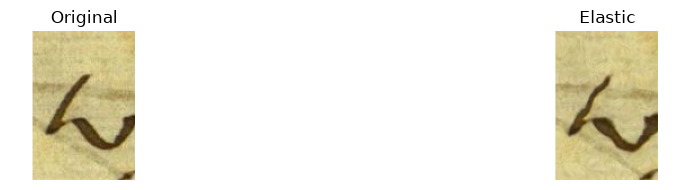

In [4]:
_page_cache: dict = {}

def crop_line(image_path: str, bbox: tuple) -> Image.Image:
    if image_path not in _page_cache:
        _page_cache[image_path] = Image.open(image_path).convert("RGB")
    return _page_cache[image_path].crop(bbox)


def pad_to_square(img: Image.Image, fill: int = 255) -> Image.Image:
    w, h   = img.size
    size   = max(w, h)
    canvas = Image.new("RGB", (size, size), (fill, fill, fill))
    canvas.paste(img, ((size - w) // 2, (size - h) // 2))
    return canvas


ELASTIC_ALPHA = 30.0
ELASTIC_SIGMA = 4.0
P_ELASTIC     = 0.5


def elastic_transform(img: Image.Image) -> Image.Image:
    arr     = np.array(img)
    h, w    = arr.shape[:2]
    rng     = np.random.RandomState()
    dx      = gaussian_filter((rng.rand(h, w) * 2 - 1), ELASTIC_SIGMA) * ELASTIC_ALPHA
    dy      = gaussian_filter((rng.rand(h, w) * 2 - 1), ELASTIC_SIGMA) * ELASTIC_ALPHA
    xs, ys  = np.meshgrid(np.arange(w), np.arange(h))
    indices = (
        np.clip(ys + dy, 0, h - 1).ravel(),
        np.clip(xs + dx, 0, w - 1).ravel(),
    )
    out = np.stack(
        [map_coordinates(arr[:, :, c], indices, order=1, mode="reflect").reshape(h, w)
         for c in range(arr.shape[2])],
        axis=2,
    )
    return Image.fromarray(out.astype(np.uint8))


# Sanity check
row = df_train.iloc[42]
raw = crop_line(row["image_path"], row["bbox"])
fig, axes = plt.subplots(1, 2, figsize=(14, 2))
axes[0].imshow(pad_to_square(raw));                  axes[0].set_title("Original");  axes[0].axis("off")
axes[1].imshow(pad_to_square(elastic_transform(raw))); axes[1].set_title("Elastic"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## Step 4 — Load Model from Epoch-10 Checkpoint

In [5]:
processor = AutoProcessor.from_pretrained(
    CKPT_IN, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS,
)

# bfloat16 instead of float16:
# • Same 2 bytes/param → identical VRAM usage
# • Exponent range = float32 → Adafactor's p.float() → bf16 cast-back cannot overflow
# • float16 range is 5e-8..65504; a converged model's tiny gradients make Adafactor
#   second moments near-zero → update spikes → fp16 overflow → NaN from epoch 2
model = Qwen3VLForConditionalGeneration.from_pretrained(
    CKPT_IN, torch_dtype=torch.bfloat16,
)

model.model.visual.requires_grad_(False)
model.model.visual.merger.requires_grad_(True)
model.lm_head.requires_grad_(False)
model.model.language_model.embed_tokens.requires_grad_(False)

model.gradient_checkpointing_enable()
model.config.use_cache = False
model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total     : {total / 1e6:.1f}M")
print(f"Trainable : {trainable / 1e6:.1f}M  ({trainable / total * 100:.1f}%)")
print(f"dtype     : {next(model.parameters()).dtype}")

large = [(n, p.numel()) for n, p in model.named_parameters()
         if p.requires_grad and p.numel() > 100_000_000]
print("WARNING — large trainable tensors:", large) if large else print("OK — no large trainable tensors")

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Total     : 2127.5M
Trainable : 1434.6M  (67.4%)
dtype     : torch.bfloat16
OK — no large trainable tensors


## Step 5 — Prompt & Training Sample Builder

In [6]:
PROMPT = (
    "You are transcribing a document from the Ratsprotokolle collection — "
    "minutes of council meetings held in Bolzano from 1470 to 1805. "
    "Language: Early Modern German. Script: historical German cursive. "
    "Multiple authors, exact number unknown. "
    "Transcribe the handwritten text in this image exactly as it appears, "
    "preserving all special characters, abbreviations, and diacritics. "
    "Output only the transcription — nothing else."
)


def build_training_sample(pil_image: Image.Image, transcription: str,
                           augment: bool = False) -> dict:
    if augment and random.random() < P_ELASTIC:
        pil_image = elastic_transform(pil_image)
    img = pad_to_square(pil_image)

    # Pass 1: prompt only → reliable prompt token length
    prompt_msgs = [{"role": "user", "content": [
        {"type": "image", "image": img}, {"type": "text", "text": PROMPT},
    ]}]
    prompt_text   = processor.apply_chat_template(
        prompt_msgs, tokenize=False, add_generation_prompt=True
    )
    prompt_inputs = processor(text=[prompt_text], images=[img], return_tensors="pt")
    prompt_len    = prompt_inputs.input_ids.shape[1]

    # Pass 2: full conversation
    full_msgs = [
        {"role": "user", "content": [
            {"type": "image", "image": img}, {"type": "text", "text": PROMPT},
        ]},
        {"role": "assistant", "content": transcription},
    ]
    full_text   = processor.apply_chat_template(full_msgs, tokenize=False, add_generation_prompt=False)
    full_inputs = processor(text=[full_text], images=[img], return_tensors="pt")

    labels = full_inputs.input_ids.clone()
    labels[0, :prompt_len] = -100
    sample = dict(full_inputs)
    sample["labels"] = labels
    return sample


row   = df_train.iloc[0]
s     = build_training_sample(crop_line(row["image_path"], row["bbox"]),
                               row["transcription"])
n_tok = (s["labels"][0] != -100).sum().item()
print(f"input_ids : {s['input_ids'].shape}  |  response tokens : {n_tok}")

input_ids : torch.Size([1, 468])  |  response tokens : 6


## Step 6 — Training (Epochs 11–20)

In [7]:
import math

EPOCHS        = 10
LR            = 2e-5
GRAD_ACCUM    = 8
PATIENCE      = 3
VAL_SUBSAMPLE = 200

cer_metric = evaluate.load("cer")

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = Adafactor(
    trainable_params,
    lr=LR,
    clip_threshold=0.5,        # extra guard: caps RMS of the update at 0.5
    scale_parameter=False,
    relative_step=False,
    warmup_init=False,
)

total_steps  = (len(df_train) * EPOCHS) // GRAD_ACCUM
scheduler    = get_scheduler("cosine", optimizer,
                              num_warmup_steps=total_steps // 20,
                              num_training_steps=total_steps)

print(f"LR {LR}  |  steps {total_steps}  |  elastic α={ELASTIC_ALPHA} σ={ELASTIC_SIGMA} p={P_ELASTIC}")


def val_cer_fast(df_sub, model, processor, device):
    model.eval()
    preds, refs = [], []
    with torch.no_grad():
        for _, row in tqdm(df_sub.iterrows(), total=len(df_sub), desc="  val", leave=False):
            img  = pad_to_square(crop_line(row["image_path"], row["bbox"]))
            msgs = [{"role": "user", "content": [
                {"type": "image", "image": img}, {"type": "text", "text": PROMPT},
            ]}]
            inputs    = processor.apply_chat_template(
                msgs, tokenize=True, add_generation_prompt=True,
                return_dict=True, return_tensors="pt",
            ).to(device)
            generated = model.generate(**inputs, max_new_tokens=128, do_sample=False)
            trimmed   = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated)]
            pred = processor.batch_decode(trimmed, skip_special_tokens=True,
                                           clean_up_tokenization_spaces=False)[0].strip()
            preds.append(pred)
            refs.append(row["transcription"])
            del inputs, generated
    torch.cuda.empty_cache()
    return cer_metric.compute(predictions=preds, references=refs)


df_val_sub   = df_val.sample(VAL_SUBSAMPLE, random_state=SEED).reset_index(drop=True)
best_cer     = float("inf")
patience_ctr = 0
history      = []

torch.cuda.empty_cache()

for epoch in range(1, EPOCHS + 1):

    model.train()
    total_loss  = 0.0
    valid_steps = 0
    optimizer.zero_grad()

    df_shuffled = df_train.sample(frac=1, random_state=SEED + epoch).reset_index(drop=True)

    for step, (_, row) in enumerate(
        tqdm(df_shuffled.iterrows(), total=len(df_shuffled),
             desc=f"Epoch {epoch:02d}/{EPOCHS}", leave=False)
    ):
        img    = crop_line(row["image_path"], row["bbox"])
        sample = build_training_sample(img, row["transcription"], augment=True)
        inputs = {k: v.to(device) for k, v in sample.items()}

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            outputs = model(**inputs)

        loss_val = outputs.loss.item()

        # Skip step on NaN/Inf loss (safety net; should not trigger with bfloat16)
        if not math.isfinite(loss_val):
            print(f"\n[skip step {step} — loss={loss_val}]", end="")
            del inputs, outputs, sample
            torch.cuda.empty_cache()
            if (step + 1) % GRAD_ACCUM == 0:
                optimizer.zero_grad()
            continue

        loss = outputs.loss / GRAD_ACCUM
        loss.backward()
        total_loss  += loss_val
        valid_steps += 1

        del inputs, outputs, sample, loss
        torch.cuda.empty_cache()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()

    avg_loss = total_loss / max(valid_steps, 1)
    val_cer  = val_cer_fast(df_val_sub, model, processor, device)

    history.append({"epoch": epoch, "train_loss": avg_loss, "val_cer": val_cer})
    print(f"Epoch {epoch:02d} | Loss {avg_loss:.4f} | Val CER {val_cer:.4f}", end="")

    if val_cer < best_cer:
        best_cer     = val_cer
        patience_ctr = 0
        model.save_pretrained(CKPT_DIR)
        processor.save_pretrained(CKPT_DIR)
        print("  ✓ saved")
    else:
        patience_ctr += 1
        print(f"  ({patience_ctr}/{PATIENCE})")
        if patience_ctr >= PATIENCE:
            print(f"Early stopping — best Val CER: {best_cer:.4f}")
            break

LR 2e-05  |  steps 8925  |  elastic α=30.0 σ=4.0 p=0.5


Epoch 01/10:   0%|          | 0/7140 [00:00<?, ?it/s]

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  val:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 01 | Loss 0.0523 | Val CER 0.1739

...

  val:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 09 | Loss 0.0148 | Val CER 0.1648  (1/3)


Epoch 10/10:   0%|          | 0/7140 [00:00<?, ?it/s]

  val:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 10 | Loss 0.0148 | Val CER 0.1661  (2/3)


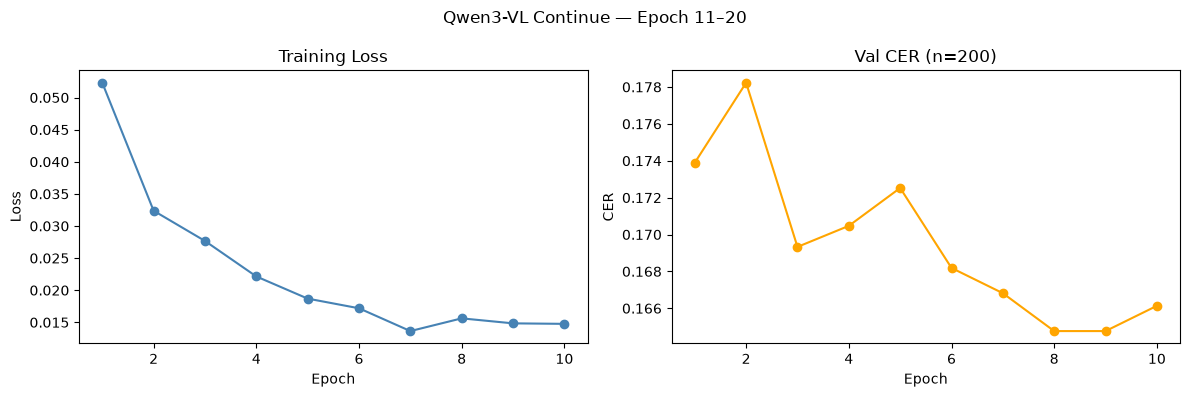

Best Val CER: 0.1648  (Epoch 8)


In [8]:
history_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_df["epoch"], history_df["train_loss"], marker="o", color="steelblue")
ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax2.plot(history_df["epoch"], history_df["val_cer"], marker="o", color="orange")
ax2.set_title(f"Val CER (n={VAL_SUBSAMPLE})"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("CER")
plt.suptitle("Qwen3-VL Continue — Epoch 11–20", fontsize=12)
plt.tight_layout()
plt.savefig(CKPT_DIR / "training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best Val CER: {history_df['val_cer'].min():.4f}  (Epoch {history_df['val_cer'].idxmin() + 1})")

## Step 7 — Evaluation on Test Set

In [9]:
# Free the training model — it still occupies ~4 GB of VRAM and would OOM a second load
try:
    del model
    torch.cuda.empty_cache()
except NameError:
    pass

eval_processor = AutoProcessor.from_pretrained(
    CKPT_DIR, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS
)
eval_model = Qwen3VLForConditionalGeneration.from_pretrained(
    CKPT_DIR, torch_dtype=torch.bfloat16
).to(device)
eval_model.eval()
print(f"Loaded from {CKPT_DIR}")

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Loaded from ../checkpoints/best_qwen_ft_read_continue


In [10]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

all_preds, all_refs = [], []

with torch.no_grad():
    for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Evaluating"):
        img  = pad_to_square(crop_line(row["image_path"], row["bbox"]))
        msgs = [{"role": "user", "content": [
            {"type": "image", "image": img}, {"type": "text", "text": PROMPT},
        ]}]
        inputs    = eval_processor.apply_chat_template(
            msgs, tokenize=True, add_generation_prompt=True,
            return_dict=True, return_tensors="pt"
        ).to(device)
        generated = eval_model.generate(**inputs, max_new_tokens=128, do_sample=False)
        trimmed   = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated)]
        pred = eval_processor.batch_decode(
            trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0].strip()
        all_preds.append(pred)
        all_refs.append(row["transcription"])

ft_cer = cer_metric.compute(predictions=all_preds, references=all_refs)
ft_wer = wer_metric.compute(predictions=all_preds, references=all_refs)
print(f"\nQwen3-VL-2B (continued, epoch 11–20)")
print(f"  CER : {ft_cer * 100:.2f}%")
print(f"  WER : {ft_wer * 100:.2f}%")

Evaluating:   0%|          | 0/1138 [00:00<?, ?it/s]


Qwen3-VL-2B (continued, epoch 11–20)
  CER : 19.96%
  WER : 46.36%


## Step 8 — Comparison Table

In [11]:
zeroshot_preds_path = ROOT / "checkpoints" / "qwen3vl_read_predictions.json"
zeroshot_cer, zeroshot_wer = None, None
if zeroshot_preds_path.exists():
    with open(zeroshot_preds_path, encoding="utf-8") as f:
        zs_preds = json.load(f)
    if len(zs_preds) == len(all_refs):
        zeroshot_cer = round(cer_metric.compute(predictions=zs_preds, references=all_refs) * 100, 2)
        zeroshot_wer = round(wer_metric.compute(predictions=zs_preds, references=all_refs) * 100, 2)

rows = [
    {"Modell": "TrOCR Elastic Aug",         "Typ": "Fine-tuned",  "CER (%)": 7.02,  "WER (%)": 28.69},
    {"Modell": "Qwen3-VL-2B epoch 1–10",    "Typ": "Fine-tuned",  "CER (%)": 16.93, "WER (%)": None},
    {"Modell": "Qwen3-VL-2B epoch 11–20",   "Typ": "Fine-tuned",  "CER (%)": round(ft_cer * 100, 2), "WER (%)": round(ft_wer * 100, 2)},
]
if zeroshot_cer is not None:
    rows.insert(0, {"Modell": "Qwen3-VL-2B zero-shot", "Typ": "Zero-shot",
                    "CER (%)": zeroshot_cer, "WER (%)": zeroshot_wer})

df_results = pd.DataFrame(rows).set_index("Modell")
print("READ Test Set (ICFHR 2016)")
display(df_results.sort_values("CER (%)"))

READ Test Set (ICFHR 2016)


,Typ,CER (%),WER (%)
Modell,,,
TrOCR Elastic Aug,Fine-tuned,7.02,28.69
Qwen3-VL-2B epoch 1–10,Fine-tuned,16.93,NaN
Qwen3-VL-2B epoch 11–20,Fine-tuned,19.96,46.36
Qwen3-VL-2B zero-shot,Zero-shot,163.90,251.04


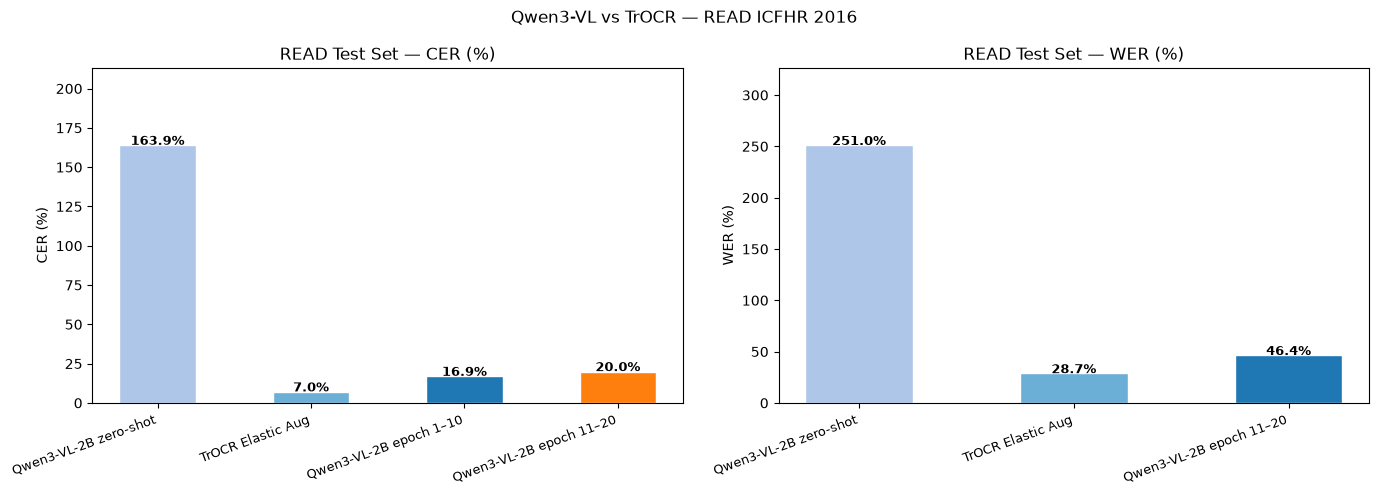

In [12]:
plot_df = df_results.dropna(subset=["CER (%)"])
labels  = plot_df.index.tolist()
colors  = ["#aec7e8", "#6baed6", "#1f77b4", "#ff7f0e"][:len(labels)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["CER (%)", "WER (%)"]):
    sub  = df_results.dropna(subset=[metric])
    lbs  = sub.index.tolist()
    vals = sub[metric].values
    bars = ax.bar(lbs, vals, color=colors[:len(lbs)], edgecolor="white", width=0.5)
    ax.set_title(f"READ Test Set — {metric}"); ax.set_ylabel(metric)
    ax.set_xticks(range(len(lbs)))
    ax.set_xticklabels(lbs, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, max(vals) * 1.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Qwen3-VL vs TrOCR — READ ICFHR 2016", fontsize=12)
plt.tight_layout()
plt.savefig(CKPT_DIR / "comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9 — Worst Predictions

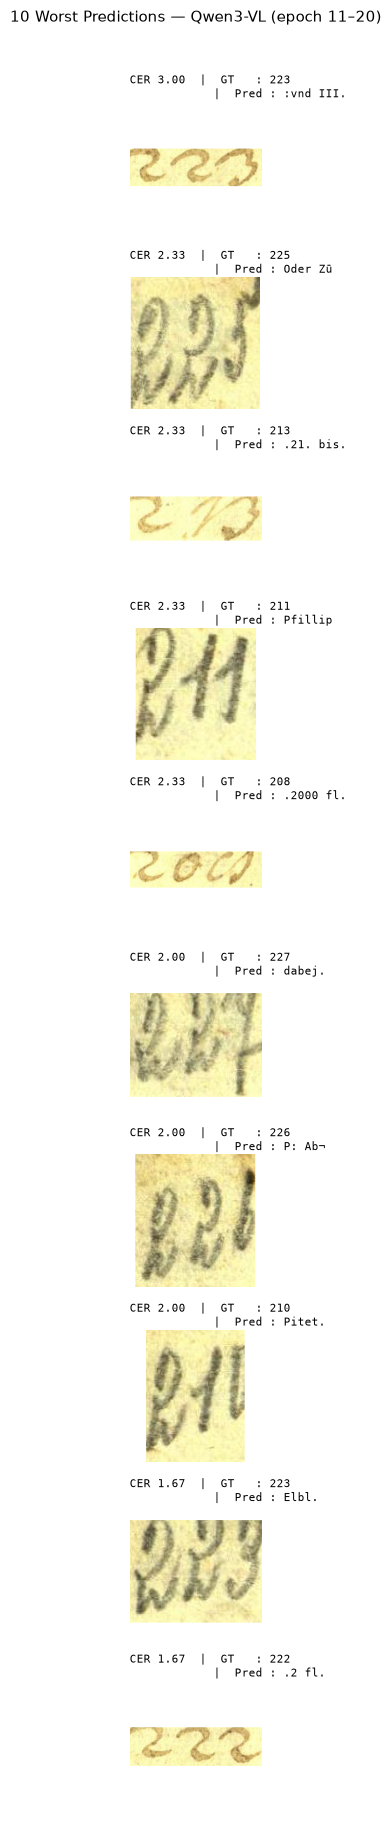

In [13]:
from jiwer import cer as line_cer

errors = sorted(
    [(line_cer(ref, pred), idx, ref, pred)
     for idx, (pred, ref) in enumerate(zip(all_preds, all_refs)) if ref.strip()],
    reverse=True,
)[:10]

fig, axes = plt.subplots(10, 1, figsize=(16, 18))
for ax, (c, idx, ref, pred) in zip(axes, errors):
    row = df_test.iloc[idx]
    ax.imshow(pad_to_square(crop_line(row["image_path"], row["bbox"])))
    ax.set_title(
        f"CER {c:.2f}  |  GT   : {ref}\n"
        f"            |  Pred : {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")

plt.suptitle("10 Worst Predictions — Qwen3-VL (epoch 11–20)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(CKPT_DIR / "worst_predictions.png", dpi=150, bbox_inches="tight")
plt.show()